===== ORIGINAL DATA =====
    Order_ID  Customer_Name                          Email   Phone_Number  \
0  ORD100000    Aarav Verma      aarav.verma8936@gmail.com     ABCDE12345   
1  ORD100001  Arjun Johnson    arjun.johnson7528@gmail.com   +88525138707   
2  ORD100002  Liam Anderson  liam.anderson7574@company.com  +919974524834   
3  ORD100003   Meena Wilson   meena.wilson6544@outlook.com  +916594130308   
4  ORD100004    David Verma    david.verma2592@company.com  +919101361778   

   Gender   Age           City           State    Country Product_Category  \
0   Other  35.0  Visakhapatnam   Andra Pradesh      India         Clothing   
1   Other  28.0        Toronto         Ontario     Canada      Electronics   
2    male  43.0      Singapore  Central Region  Singapore      Electronics   
3   Other  53.0        Chennai      Tamil Nadu      India         Clothing   
4  Female  52.0       New York        New York        USA       Healthcare   

      Product_Name  Quantity  Unit_Price  

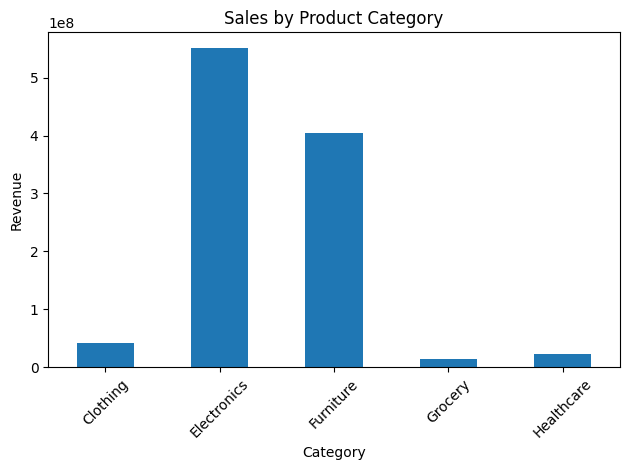

Chart saved!

===== CLEANING COMPLETED SUCCESSFULLY =====


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("business_sales.csv")

print("===== ORIGINAL DATA =====")
print(df.head())

df = df.drop_duplicates()

df["Product_Name"] = df["Product_Name"].fillna("Unknown Product")

df["Customer_Rating"] = df["Customer_Rating"].fillna(
    df["Customer_Rating"].mean()
)

df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

df["Gender"] = df["Gender"].str.title()

df["City"] = df["City"].str.title()

df["Payment_Method"] = df["Payment_Method"].str.title()

df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
)

df = df[
    df["Phone_Number"]
    .astype(str)
    .str.contains(r"\+91|[0-9]", regex=True)
]

df = df[df["Quantity"] > 0]

df = df[df["Unit_Price"] > 0]

df.to_excel(
    r"C:\Users\ASUS\Downloads\cleaned_business_sales.xlsx",
    index=False
)

print("\nCleaned dataset saved!")

summary = {
    "Total Orders": len(df),

    "Total Revenue": df["Total_Amount"].sum(),

    "Average Rating": round(
        df["Customer_Rating"].mean(),
        2
    ),

    "Top Revenue Category": (
        df.groupby("Product_Category")["Total_Amount"]
        .sum()
        .idxmax()
    )
}

summary_df = pd.DataFrame([summary])

summary_df.to_excel(
    r"C:\Users\ASUS\Downloads\summary_report.xlsx",
    index=False
)

print("Summary report generated!")

sales_by_category = (
    df.groupby("Product_Category")["Total_Amount"]
    .sum()
)

sales_by_category.plot(kind="bar")

plt.title("Sales by Product Category")

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    r"C:\Users\ASUS\Downloads\sales_chart.png"
)

plt.show()

print("Chart saved!")

print("\n===== CLEANING COMPLETED SUCCESSFULLY =====")